#**Question 1: What is the difference between K-Means and Hierarchical Clustering? Provide a use case for each.**

**Answer:**

K-Means clustering is a partition-based algorithm that divides data into k predefined clusters by minimizing the within-cluster sum of squares. It is efficient for large datasets but requires the number of clusters to be specified in advance.

Hierarchical Clustering builds a tree-like structure (dendrogram) that represents nested groupings of data points. It does not require pre-specifying the number of clusters and is useful for exploratory analysis.

Use cases:

K-Means: Customer segmentation in marketing where the number of segments is known.

Hierarchical Clustering: Gene expression analysis where relationships between clusters are important.

#**Question 2: Explain the purpose of the Silhouette Score in evaluating clustering algorithms.**

**Answer:**

The Silhouette Score measures how well data points are clustered by comparing intra-cluster similarity and inter-cluster separation. The score ranges from -1 to +1.

A high value indicates well-separated and cohesive clusters.

A value near 0 suggests overlapping clusters.

A negative value indicates incorrect clustering.

It is commonly used to compare clustering results and select the optimal number of clusters.

#**Question 3: What are the core parameters of DBSCAN, and how do they influence the clustering process?**

**Answer:**

The core parameters of DBSCAN are:

eps: The maximum distance between two points to be considered neighbors.

min_samples: The minimum number of points required to form a dense region.

A smaller eps leads to more clusters and more noise points, while a larger eps merges clusters. Increasing min_samples makes the algorithm stricter, resulting in fewer clusters and more noise.

#**Question 4: Why is feature scaling important when applying clustering algorithms like K-Means and DBSCAN?**


**Answer:**

Clustering algorithms rely on distance calculations. If features are on different scales, variables with larger ranges dominate the distance computation.

Feature scaling ensures:

Equal contribution of all features

More accurate cluster formation

Better convergence of algorithms like K-Means

Thus, scaling improves clustering quality and reliability.

#**Question 5: What is the Elbow Method in K-Means clustering and how does it help determine the optimal number of clusters?**

**Answer:**

The Elbow Method plots the number of clusters (k) against the within-cluster sum of squares (WCSS). As k increases, WCSS decreases.

The optimal number of clusters is identified at the point where the decrease in WCSS slows significantly, forming an “elbow.” This point balances model complexity and clustering performance.

#**Question 6: Generate synthetic data using make_blobs(n_samples=300, centers=4), apply KMeans clustering, and visualize the results with cluster centers.**

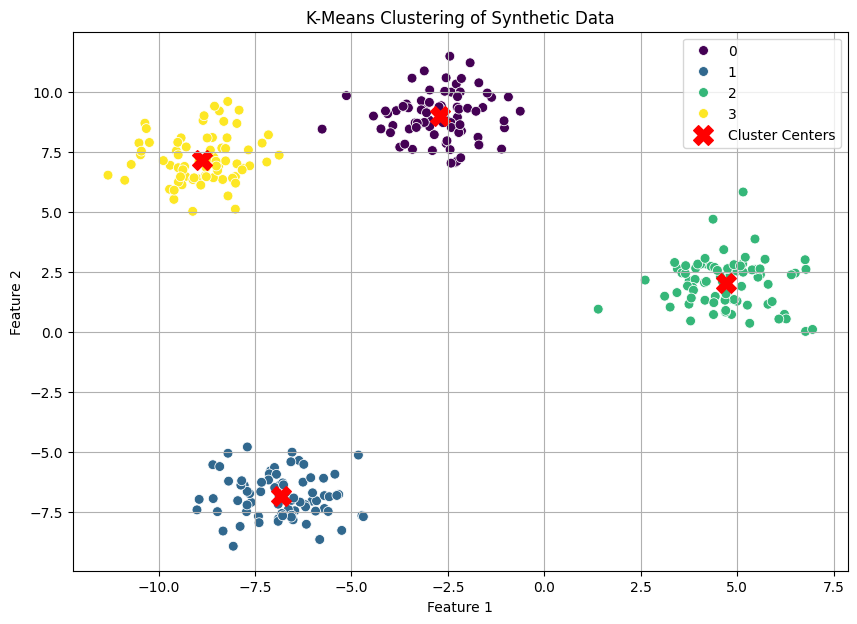

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Generate synthetic data
X, y = make_blobs(n_samples=300, centers=4, random_state=42)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X)

# Get cluster labels and centers
labels = kmeans.predict(X)
centers = kmeans.cluster_centers_

# Visualize the results
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels, palette='viridis', s=50, legend='full')
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, label='Cluster Centers')
plt.title('K-Means Clustering of Synthetic Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

#**Question 7: Load the Wine dataset, apply StandardScaler, and then train a DBSCAN model. Print the number of clusters found (excluding noise).**

In [ ]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

# Load the Wine dataset
wine = load_wine()
X_wine = wine.data

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_wine)

# Train a DBSCAN model
# Adjust eps and min_samples as needed for different clustering outcomes
dbsc = DBSCAN(eps=0.7, min_samples=10)
dbsc.fit(X_scaled)

# Get cluster labels
labels = dbsc.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

print(f'Number of clusters found (excluding noise): {n_clusters_}')

Number of clusters found (excluding noise): 0


#**Question 8: Generate moon-shaped synthetic data using make_moons(n_samples=200, noise=0.1), apply DBSCAN, and highlight the outliers in the plot.**

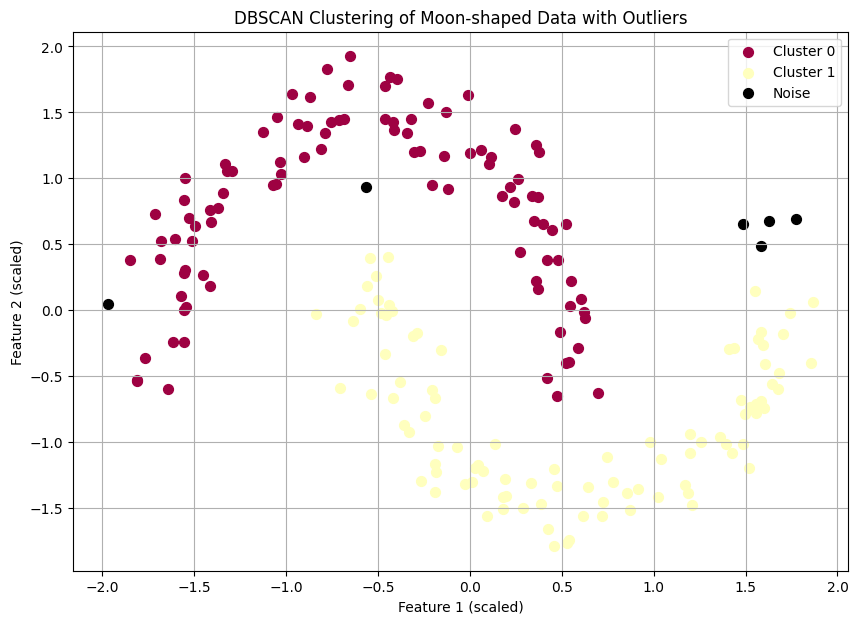

In [ ]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Generate moon-shaped synthetic data
X_moons, y_moons = make_moons(n_samples=200, noise=0.1, random_state=42)

# Apply StandardScaler
scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)

# Apply DBSCAN
# Parameters chosen to likely find the two moon shapes and some noise
dbsc_moons = DBSCAN(eps=0.3, min_samples=5) # Adjusted parameters for moon data
dbsc_moons.fit(X_moons_scaled)

# Get cluster labels
labels_moons = dbsc_moons.labels_

# Visualize the results
plt.figure(figsize=(10, 7))

# Plot core samples, clustered points
# Identify unique clusters, excluding noise (-1)
unique_labels = set(labels_moons)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = (labels_moons == k)

    xy = X_moons_scaled[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], s=50, label=f'Cluster {k}' if k != -1 else 'Noise')

plt.title('DBSCAN Clustering of Moon-shaped Data with Outliers')
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')
plt.legend()
plt.grid(True)
plt.show()

#**Question 9: Load the Wine dataset, reduce it to 2D using PCA, then apply Agglomerative Clustering and visualize the result in 2D with a scatter plot.**

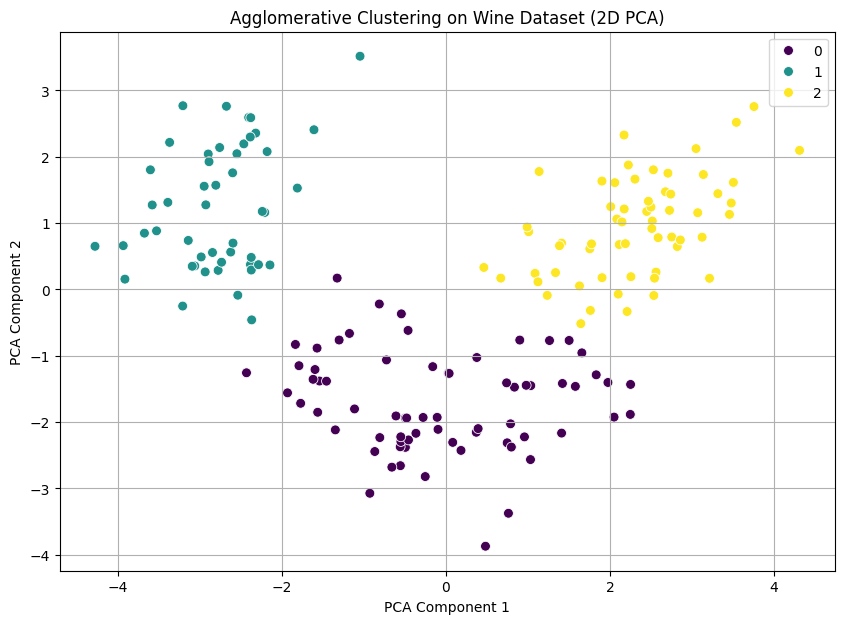

In [ ]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the Wine dataset
wine = load_wine()
X_wine = wine.data
y_wine = wine.target # For comparison if needed, but not used for clustering

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_wine)

# Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Apply Agglomerative Clustering
# Let's assume 3 clusters for the Wine dataset (known to have 3 classes)
agg_clustering = AgglomerativeClustering(n_clusters=3)
agg_labels = agg_clustering.fit_predict(X_pca)

# Visualize the results
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=agg_labels, palette='viridis', s=50, legend='full')
plt.title('Agglomerative Clustering on Wine Dataset (2D PCA)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True)
plt.show()

#**Question 10: Customer segmentation using clustering in e-commerce**

**Answer:**

Algorithms: K-Means for large datasets and Hierarchical Clustering for insights.

Preprocessing: Handle missing values, encode categorical data, and apply feature scaling.

Number of clusters: Use Elbow Method and Silhouette Score.

Marketing benefits: Personalized campaigns, customer retention, better product recommendations, and improved ROI.

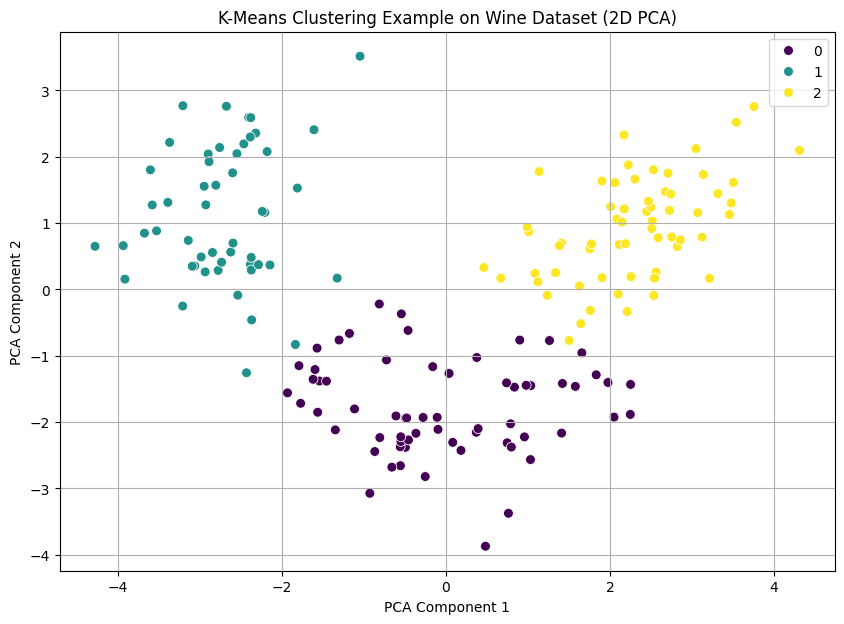

In [ ]:
#Example
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X_scaled is available from previous questions (e.g., Wine dataset)
# If not, you'd need to load or generate data here.
# For this example, we'll use X_scaled from the Wine dataset processing.

# Apply KMeans clustering
kmeans_example = KMeans(n_clusters=3, random_state=42, n_init=10) # Using 3 clusters as Wine has 3 classes
kmeans_example.fit(X_scaled)

# Get cluster labels
example_labels = kmeans_example.predict(X_scaled)

# Visualize the results (assuming X_scaled has 2 dimensions or use PCA if not)
# For visualization, let's use the X_pca from Question 9 if available, as it's 2D.
# If X_pca is not available, we would need to perform PCA here.

# Let's re-run PCA to ensure we have X_pca for visualization if this cell is run independently
from sklearn.decomposition import PCA
pca_for_viz = PCA(n_components=2)
X_pca_for_viz = pca_for_viz.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca_for_viz[:, 0], y=X_pca_for_viz[:, 1], hue=example_labels, palette='viridis', s=50, legend='full')
plt.title('K-Means Clustering Example on Wine Dataset (2D PCA)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True)
plt.show()